In [27]:
#Primero de todo importamos las librerías necesarias para el proyecto

#Librerias para la creacion de los modelos
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import MinMaxScaler

#Librerias para la carga de los datos
from ucimlrepo import fetch_ucirepo 

#Libreria para dibujar graficos
import matplotlib.pyplot as plt


In [28]:
#creamos el modelo de la red neuronal
def create_model(X_train):
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        layers.Dense(32, activation='relu'),
        layers.Dense(2, activation='softmax')
    ])
    
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# ===== FUNCIÓN DE PLOTEO =====
def plot_training_history_leg(history_leg):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history_leg.history['loss'], label='Pérdida entrenamiento')
    plt.plot(history_leg.history['val_loss'], label='Pérdida validación')
    plt.title('Pérdida')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history_leg.history['accuracy'], label='Precisión entrenamiento')
    plt.plot(history_leg.history['val_accuracy'], label='Precisión validación')
    plt.title('Precisión')
    plt.legend()
    
    plt.tight_layout()
    plt.show()



In [ ]:
#Importamos el dataSet
magic_gamma_telescope = fetch_ucirepo(id=159) 
  
X = magic_gamma_telescope.data.features 
y = magic_gamma_telescope.data.targets 


#Separamos el dataset en entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Normalizamos los datos para que el entrenamiento sea más eficiente entre -1 y 1
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

input_dim = X_train.shape[1]


#Cambiamos las etiquetas a 0 y 1
y_train = (y_train == 'g').astype(int)
y_test = (y_test == 'g').astype(int)

In [30]:
def createEarlyStoppingCallback(patience=15):
    return keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

In [31]:
#importamos para ir borrando el historial de entrenamiento y así evitar que se sobreescriba el mismo historial en cada modelo
from keras import backend as K

# --- Entrenamiento Grado 2 ---
K.clear_session()  # Limpiamos la sesión para evitar que los modelos compartan pesos o historial

modeloTest = create_model(X_train_scaled)
history = modeloTest.fit(X_train_scaled, y_train, validation_split=0.2, epochs=300, batch_size=32, callbacks=[createEarlyStoppingCallback()])


Epoch 1/300


d:\Programas\Anaconda\envs\Polynomial_Env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7494 - loss: 0.5063 - val_accuracy: 0.7983 - val_loss: 0.4453
Epoch 2/300
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8088 - loss: 0.4214 - val_accuracy: 0.8058 - val_loss: 0.4264
Epoch 3/300
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8223 - loss: 0.3999 - val_accuracy: 0.8285 - val_loss: 0.4010
Epoch 4/300
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8279 - loss: 0.3908 - val_accuracy: 0.8196 - val_loss: 0.4088
Epoch 5/300
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8321 - loss: 0.3794 - val_accuracy: 0.8325 - val_loss: 0.3848
Epoch 6/300
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8427 - loss: 0.3709 - val_accuracy: 0.8371 - val_loss: 0.3764
Epoch 7/300
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8454 - loss: 0.3646 - val_accuracy: 0.8400 - val_loss: 0.3711
Epoch 8/300
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8492 - loss: 0.3570 - val_accuracy: 0.8466

In [34]:
#Imprimimos el resultado del modelo
test_loss, test_accuracy = modeloTest.evaluate(X_test_scaled, y_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8754 - loss: 0.3004
Test Loss: 0.3004, Test Accuracy: 0.8754


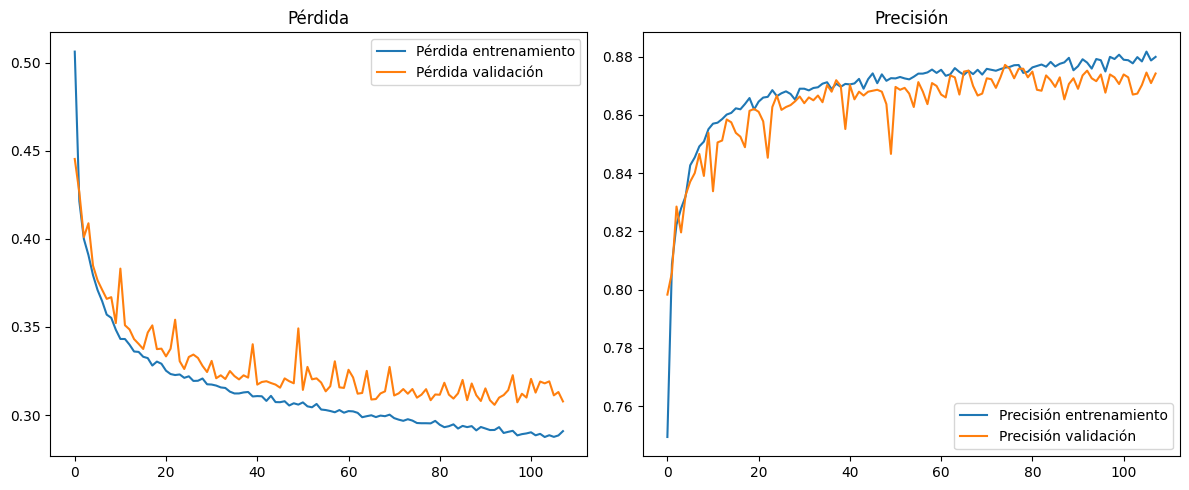

In [33]:
#Dibjamos el historial de entrenamiento
plot_training_history_leg(history)